# Crawl — Maze Crawler Agent
A strategic agent for the Kaggle Crawl competition: navigate an infinite northward-scrolling maze, build robots, collect energy, and outlast the opponent.

**Competition files** are in `maze-crawler/` (extracted from `maze-crawler.zip`):
- `maze-crawler/main.py` — starter agent template
- `maze-crawler/AGENTS.md` — submission guide (how to test and submit)
- `maze-crawler/README.md` — full game rules and observation format

In [32]:
!pip install -q kaggle-environments

## Upload Competition Files (optional)
Run this cell to upload the competition zip (or individual files like `main.py`) from your computer.  
Skip if `maze-crawler/` is already present in the working directory.

In [33]:
import pathlib, zipfile, io

def _handle_file(fname: str, data: bytes):
    if fname.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(data)) as zf:
            zf.extractall('.')
        print(f'Extracted {fname} → current directory')
        items = [p.name for p in sorted(pathlib.Path('.').iterdir()) if not p.name.startswith('.')]
        print('Items:', items)
    else:
        dest = pathlib.Path('maze-crawler')
        dest.mkdir(parents=True, exist_ok=True)
        (dest / fname).write_bytes(data)
        print(f'Saved {fname} → maze-crawler/{fname}')

try:
    # Google Colab
    from google.colab import files as _colab_files
    print('Colab detected — click "Choose Files" to upload.')
    for fname, data in _colab_files.upload().items():
        _handle_file(fname, data)

except ImportError:
    # Local Jupyter / JupyterLab
    import ipywidgets as widgets
    from IPython.display import display

    uploader = widgets.FileUpload(
        accept='.zip,.py,.json,.csv',
        multiple=True,
        description='Upload',
        layout=widgets.Layout(width='260px'),
    )
    out = widgets.Output()

    def _on_upload(change):
        with out:
            out.clear_output()
            val = uploader.value
            # ipywidgets >= 8 returns a tuple of dicts; < 8 returns a filename→info dict
            if isinstance(val, dict):
                items = [(fname, bytes(info['content'])) for fname, info in val.items()]
            else:
                items = [(f['name'], bytes(f['content'])) for f in val]
            for fname, data in items:
                _handle_file(fname, data)

    uploader.observe(_on_upload, names='value')
    display(widgets.VBox([
        widgets.Label('Upload competition zip or individual files:'),
        uploader,
        out,
    ]))

Colab detected — click "Choose Files" to upload.


Saving AGENTS.md to AGENTS.md
Saving main.py to main.py
Saving README.md to README.md
Saved AGENTS.md → maze-crawler/AGENTS.md
Saved main.py → maze-crawler/main.py
Saved README.md → maze-crawler/README.md


In [34]:
from kaggle_environments import make
import numpy as np
import pathlib

# Root of the extracted competition files
COMP_DIR = pathlib.Path('maze-crawler')
print('Competition files:', [p.name for p in sorted(COMP_DIR.iterdir()) if not p.name.endswith('.zip')])

Competition files: ['AGENTS.md', 'README.md', 'main (1).py', 'main.py']


## Competition Files — Quick Reference
Read the AGENTS guide (submission workflow) and the starter agent from the extracted directory.

In [35]:
# Show submission guide from the extracted zip
agents_md = (COMP_DIR / 'AGENTS.md').read_text(encoding='utf-8')
print(agents_md[:3000])

# Crawl: Getting Started

This guide walks you through building an agent, testing it locally, and submitting it to the Crawl competition on Kaggle.

## Game Overview

Crawl is a two-player real-time strategy game on a 20-wide maze that scrolls northward over time. Each player starts with a single **Factory** and must build robots to explore, collect energy, and outlast the opponent.

- **Factory** (indestructible) builds Scouts, Workers, and Miners; can JUMP every 20 turns
- **Scout** (cost 50) is fast with vision range 5 — your eyes
- **Worker** (cost 200) builds and removes walls (100 energy per action)
- **Miner** (cost 300) can `TRANSFORM` on a mining node into a mine that generates 50 energy/turn
- **Maze** has east/west symmetry with occasional doors; both players see only what their robots see (fog of war)
- **Combat**: when robots end the turn on the same cell, crush rules apply (Factory > Miner > Worker > Scout). Same-type collisions destroy all parties — friendly fire is real

In [36]:
# Starter agent from the extracted zip (for reference)
starter_code = (COMP_DIR / 'main.py').read_text(encoding='utf-8')
print('--- starter main.py ---')
print(starter_code)

--- starter main.py ---
"""Crawl starter agent: build a worker, march north, knock down walls."""

from random import choice


def agent(obs, config):
    actions = {}
    width = config.width
    my_robots = {
        uid: data for uid, data in obs.robots.items()
        if data[4] == obs.player
    }

    for uid, data in my_robots.items():
        rtype, col, row, energy = data[0], data[1], data[2], data[3]
        build_cd = data[7] if len(data) > 7 else 0

        idx = (row - obs.southBound) * width + col
        w = obs.walls[idx] if 0 <= idx < len(obs.walls) and obs.walls[idx] != -1 else 0

        if rtype == 0:  # Factory
            if w & 1:
                actions[uid] = "JUMP_NORTH"
            elif energy >= config.workerCost and build_cd == 0:
                actions[uid] = "BUILD_WORKER"
            else:
                actions[uid] = "NORTH"
        elif rtype == 2 and (w & 1) and energy >= config.wallRemoveCost:
            actions[uid] = "REMOVE_NORTH"
        else

## Helper Utilities

In [37]:
# Wall bitfield: N=1, E=2, S=4, W=8
WALL_N, WALL_E, WALL_S, WALL_W = 1, 2, 4, 8
DIRECTION_BITS = {'NORTH': WALL_N, 'EAST': WALL_E, 'SOUTH': WALL_S, 'WEST': WALL_W}
DIRECTION_DELTA = {'NORTH': (0, 1), 'EAST': (1, 0), 'SOUTH': (0, -1), 'WEST': (-1, 0)}
OPPOSITE = {'NORTH': 'SOUTH', 'SOUTH': 'NORTH', 'EAST': 'WEST', 'WEST': 'EAST'}

# Robot type IDs
FACTORY, SCOUT, WORKER, MINER = 0, 1, 2, 3


def parse_robots(obs):
    """Return dicts keyed by uid for each robot category."""
    my_factory = None
    my_robots = {}   # all own robots by uid
    enemy_robots = {}

    for uid, data in obs.robots.items():
        rtype, col, row, energy, owner = data[0], data[1], data[2], data[3], data[4]
        move_cd, jump_cd, build_cd = data[5], data[6], data[7]
        info = dict(
            uid=uid, type=rtype, col=col, row=row, energy=energy,
            owner=owner, move_cd=move_cd, jump_cd=jump_cd, build_cd=build_cd
        )
        if owner == obs.player:
            my_robots[uid] = info
            if rtype == FACTORY:
                my_factory = info
        else:
            enemy_robots[uid] = info

    return my_factory, my_robots, enemy_robots


def get_wall(obs, col, row, width):
    """Return wall bitfield for a cell, or 0xF if out of range."""
    idx = (row - obs.southBound) * width + col
    if idx < 0 or idx >= len(obs.walls):
        return 0xF
    v = obs.walls[idx]
    return v if v >= 0 else 0  # undiscovered cells treated as open


def can_move(obs, col, row, direction, width):
    """True if no wall blocks movement from (col,row) in direction."""
    return not (get_wall(obs, col, row, width) & DIRECTION_BITS[direction])


def best_move_north(obs, col, row, width, occupied):
    """Greedy northward movement with fallbacks. occupied = set of (col,row)."""
    for direction in ('NORTH', 'EAST', 'WEST', 'SOUTH'):
        if not can_move(obs, col, row, direction, width):
            continue
        dc, dr = DIRECTION_DELTA[direction]
        nc, nr = col + dc, row + dr
        if nr < obs.southBound or nr > obs.northBound:
            continue  # would fall off edge
        if (nc, nr) in occupied:
            continue  # avoid friendly collision
        return direction
    return 'IDLE'


def manhattan(c1, r1, c2, r2):
    return abs(c1 - c2) + abs(r1 - r2)


def adjacent_direction(fc, fr, tc, tr):
    """Direction from (fc,fr) to adjacent (tc,tr), or None."""
    if tr == fr + 1 and tc == fc: return 'NORTH'
    if tr == fr - 1 and tc == fc: return 'SOUTH'
    if tc == fc + 1 and tr == fr: return 'EAST'
    if tc == fc - 1 and tr == fr: return 'WEST'
    return None

print('Helpers loaded.')

Helpers loaded.


## Agent Implementation

**Strategy overview**
- Factory: keep moving north ahead of the scrolling boundary; use JUMP as a panic button; build scouts early, workers when needed.
- Scouts: fan out north collecting crystals; transfer energy back to factory when adjacent and nearly full.
- Workers: remove north walls to open corridors, then push north.
- Miners: navigate to the nearest visible mining node and TRANSFORM.

In [38]:
def agent(obs, config):
    actions = {}
    width = config.width
    south = obs.southBound
    north = obs.northBound

    my_factory, my_robots, enemy_robots = parse_robots(obs)
    if my_factory is None:
        return actions

    # Cells that will be occupied after movement (avoid friendly-fire collisions)
    occupied = {(r['col'], r['row']) for r in my_robots.values()}

    fc, fr = my_factory['col'], my_factory['row']
    danger_zone = south + 4  # factory within 4 rows of boundary = danger

    # ── Factory ──────────────────────────────────────────────────────────────
    fuid = my_factory['uid']

    if my_factory['move_cd'] == 0:
        # Emergency jump if stuck in danger and cooldown ready
        if fr <= danger_zone and my_factory['jump_cd'] == 0:
            # Verify landing cell won't be off-board
            if fr + 2 <= north:
                actions[fuid] = 'JUMP_NORTH'
        elif fuid not in actions:
            # Decide whether to build or move
            scouts  = [r for r in my_robots.values() if r['type'] == SCOUT]
            workers = [r for r in my_robots.values() if r['type'] == WORKER]
            miners  = [r for r in my_robots.values() if r['type'] == MINER]

            spawn_cell = (fc, fr + 1)
            spawn_clear = (
                can_move(obs, fc, fr, 'NORTH', width)
                and spawn_cell not in occupied
            )
            build_ready = my_factory['build_cd'] == 0
            fe = my_factory['energy']

            build_action = None
            if build_ready and spawn_clear:
                if len(scouts) < 3 and fe >= config.scoutCost + 100:
                    build_action = 'BUILD_SCOUT'
                elif len(workers) < 1 and fe >= config.workerCost + 200:
                    build_action = 'BUILD_WORKER'
                elif len(scouts) < 5 and fe >= config.scoutCost + 50:
                    build_action = 'BUILD_SCOUT'
                elif len(miners) < 1 and fe >= config.minerCost + 300:
                    build_action = 'BUILD_MINER'

            if build_action and fr > danger_zone:
                actions[fuid] = build_action
            else:
                occupied.discard((fc, fr))
                move = best_move_north(obs, fc, fr, width, occupied)
                if move != 'IDLE':
                    dc, dr = DIRECTION_DELTA[move]
                    occupied.add((fc + dc, fr + dr))
                occupied.add((fc, fr))
                actions[fuid] = move

    # ── Scouts ───────────────────────────────────────────────────────────────
    for r in my_robots.values():
        if r['type'] != SCOUT or r['uid'] in actions:
            continue
        if r['move_cd'] > 0:
            continue

        sc, sr, se = r['col'], r['row'], r['energy']
        uid = r['uid']

        # Transfer surplus energy to adjacent factory
        if se > config.scoutMaxEnergy * 0.7:
            direction = adjacent_direction(sc, sr, fc, fr)
            if direction and can_move(obs, sc, sr, direction, width):
                actions[uid] = 'TRANSFER_' + direction
                continue

        # Move north greedily
        occupied.discard((sc, sr))
        move = best_move_north(obs, sc, sr, width, occupied)
        if move != 'IDLE':
            dc, dr = DIRECTION_DELTA[move]
            occupied.add((sc + dc, sr + dr))
        occupied.add((sc, sr))
        actions[uid] = move

    # ── Workers ──────────────────────────────────────────────────────────────
    for r in my_robots.values():
        if r['type'] != WORKER or r['uid'] in actions:
            continue
        if r['move_cd'] > 0:
            continue

        wc, wr, we = r['col'], r['row'], r['energy']
        uid = r['uid']

        # Remove north wall if present and we can afford it
        if (
            get_wall(obs, wc, wr, width) & WALL_N
            and we >= config.wallRemoveCost + 100
            and wr + 1 <= north
        ):
            actions[uid] = 'REMOVE_NORTH'
        else:
            occupied.discard((wc, wr))
            move = best_move_north(obs, wc, wr, width, occupied)
            if move != 'IDLE':
                dc, dr = DIRECTION_DELTA[move]
                occupied.add((wc + dc, wr + dr))
            occupied.add((wc, wr))
            actions[uid] = move

    # ── Miners ───────────────────────────────────────────────────────────────
    for r in my_robots.values():
        if r['type'] != MINER or r['uid'] in actions:
            continue
        if r['move_cd'] > 0:
            continue

        mc, mr, me = r['col'], r['row'], r['energy']
        uid = r['uid']
        cell_key = f'{mc},{mr}'

        # Transform on mining node if affordable
        if cell_key in obs.miningNodes and me >= config.transformCost:
            actions[uid] = 'TRANSFORM'
            continue

        # Navigate toward nearest visible mining node
        if obs.miningNodes:
            closest_key = min(
                obs.miningNodes,
                key=lambda k: (
                    manhattan(mc, mr, int(k.split(',')[0]), int(k.split(',')[1]))
                )
            )
            tc, tr = int(closest_key.split(',')[0]), int(closest_key.split(',')[1])

            preferred = []
            if tr > mr: preferred.append('NORTH')
            if tc > mc: preferred.append('EAST')
            if tc < mc: preferred.append('WEST')
            if tr < mr: preferred.append('SOUTH')

            move = 'IDLE'
            for d in preferred + ['NORTH', 'EAST', 'WEST']:
                if can_move(obs, mc, mr, d, width):
                    dc, dr = DIRECTION_DELTA[d]
                    nc, nr = mc + dc, mr + dr
                    if south <= nr <= north and (nc, nr) not in occupied:
                        move = d
                        break
        else:
            occupied.discard((mc, mr))
            move = best_move_north(obs, mc, mr, width, occupied)

        if move != 'IDLE':
            dc, dr = DIRECTION_DELTA[move]
            occupied.add((mc + dc, mr + dr))
        occupied.add((mc, mr))
        actions[uid] = move

    return actions


print('Agent defined.')

Agent defined.


## Run the Environment

In [39]:
env = make('crawl', configuration={'randomSeed': 42})
env.run([agent, 'random'])
print('Episode finished.')

# Check final rewards
steps = env.steps
final = steps[-1]
print(f'  Player 0 reward: {final[0]["reward"]}')
print(f'  Player 1 reward: {final[1]["reward"]}')

Episode finished.
  Player 0 reward: -463
  Player 1 reward: 760


In [40]:
env.render(mode='ipython', width=800, height=800)

## Post-game Analysis

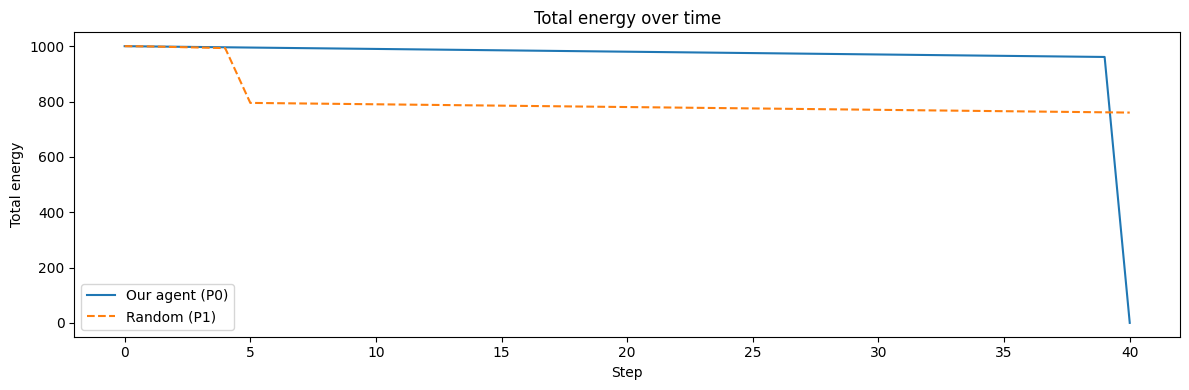

In [41]:
import matplotlib.pyplot as plt

# Collect per-step energy totals for both players
p0_energy, p1_energy = [], []

for step in env.steps:
    for pid, state in enumerate(step):
        obs_raw = state.get('observation', {})
        robots  = obs_raw.get('robots', {})
        total   = sum(
            data[3] for uid, data in robots.items() if data[4] == pid
        )
        (p0_energy if pid == 0 else p1_energy).append(total)

plt.figure(figsize=(12, 4))
plt.plot(p0_energy, label='Our agent (P0)', linewidth=1.5)
plt.plot(p1_energy, label='Random (P1)',    linewidth=1.5, linestyle='--')
plt.xlabel('Step')
plt.ylabel('Total energy')
plt.title('Total energy over time')
plt.legend()
plt.tight_layout()
plt.show()

## Self-play Benchmark (agent vs. agent)

In [42]:
env2 = make('crawl', configuration={'randomSeed': 123})
env2.run([agent, agent])

final2 = env2.steps[-1]
print(f'Self-play  P0: {final2[0]["reward"]}  P1: {final2[1]["reward"]}')
env2.render(mode='ipython', width=800, height=600)

Self-play  P0: 0.5  P1: 0.5


## Save Agent for Submission

Writes `maze-crawler/main.py` — a self-contained file with all helpers and the agent function.
Submit with:
```bash
kaggle competitions submit crawl -f maze-crawler/main.py -m "scout-worker-miner v1"
```

In [43]:
SUBMISSION_CODE = '''
# Wall bitfield: N=1, E=2, S=4, W=8
WALL_N, WALL_E, WALL_S, WALL_W = 1, 2, 4, 8
DIRECTION_BITS = {"NORTH": WALL_N, "EAST": WALL_E, "SOUTH": WALL_S, "WEST": WALL_W}
DIRECTION_DELTA = {"NORTH": (0, 1), "EAST": (1, 0), "SOUTH": (0, -1), "WEST": (-1, 0)}

FACTORY, SCOUT, WORKER, MINER = 0, 1, 2, 3


def _parse_robots(obs):
    my_factory = None
    my_robots = {}
    for uid, data in obs.robots.items():
        rtype, col, row, energy, owner = data[0], data[1], data[2], data[3], data[4]
        move_cd, jump_cd, build_cd = data[5], data[6], data[7]
        info = dict(
            uid=uid, type=rtype, col=col, row=row, energy=energy,
            owner=owner, move_cd=move_cd, jump_cd=jump_cd, build_cd=build_cd
        )
        if owner == obs.player:
            my_robots[uid] = info
            if rtype == FACTORY:
                my_factory = info
    return my_factory, my_robots


def _get_wall(obs, col, row, width):
    idx = (row - obs.southBound) * width + col
    if idx < 0 or idx >= len(obs.walls):
        return 0xF
    v = obs.walls[idx]
    return v if v >= 0 else 0


def _can_move(obs, col, row, direction, width):
    return not (_get_wall(obs, col, row, width) & DIRECTION_BITS[direction])


def _best_move_north(obs, col, row, width, occupied):
    for direction in ("NORTH", "EAST", "WEST", "SOUTH"):
        if not _can_move(obs, col, row, direction, width):
            continue
        dc, dr = DIRECTION_DELTA[direction]
        nc, nr = col + dc, row + dr
        if nr < obs.southBound or nr > obs.northBound:
            continue
        if (nc, nr) in occupied:
            continue
        return direction
    return "IDLE"


def _manhattan(c1, r1, c2, r2):
    return abs(c1 - c2) + abs(r1 - r2)


def _adjacent_dir(fc, fr, tc, tr):
    if tr == fr + 1 and tc == fc: return "NORTH"
    if tr == fr - 1 and tc == fc: return "SOUTH"
    if tc == fc + 1 and tr == fr: return "EAST"
    if tc == fc - 1 and tr == fr: return "WEST"
    return None


def agent(obs, config):
    actions = {}
    width = config.width
    south = obs.southBound
    north = obs.northBound

    my_factory, my_robots = _parse_robots(obs)
    if my_factory is None:
        return actions

    occupied = {(r["col"], r["row"]) for r in my_robots.values()}
    fc, fr = my_factory["col"], my_factory["row"]
    danger_zone = south + 4
    fuid = my_factory["uid"]

    # Factory
    if my_factory["move_cd"] == 0:
        if fr <= danger_zone and my_factory["jump_cd"] == 0 and fr + 2 <= north:
            actions[fuid] = "JUMP_NORTH"
        elif fuid not in actions:
            scouts  = [r for r in my_robots.values() if r["type"] == SCOUT]
            workers = [r for r in my_robots.values() if r["type"] == WORKER]
            miners  = [r for r in my_robots.values() if r["type"] == MINER]
            spawn_cell = (fc, fr + 1)
            spawn_clear = _can_move(obs, fc, fr, "NORTH", width) and spawn_cell not in occupied
            build_ready = my_factory["build_cd"] == 0
            fe = my_factory["energy"]
            build_action = None
            if build_ready and spawn_clear:
                if len(scouts) < 3 and fe >= config.scoutCost + 100:
                    build_action = "BUILD_SCOUT"
                elif len(workers) < 1 and fe >= config.workerCost + 200:
                    build_action = "BUILD_WORKER"
                elif len(scouts) < 5 and fe >= config.scoutCost + 50:
                    build_action = "BUILD_SCOUT"
                elif len(miners) < 1 and fe >= config.minerCost + 300:
                    build_action = "BUILD_MINER"
            if build_action and fr > danger_zone:
                actions[fuid] = build_action
            else:
                occupied.discard((fc, fr))
                move = _best_move_north(obs, fc, fr, width, occupied)
                if move != "IDLE":
                    dc, dr = DIRECTION_DELTA[move]
                    occupied.add((fc + dc, fr + dr))
                occupied.add((fc, fr))
                actions[fuid] = move

    # Scouts
    for r in my_robots.values():
        if r["type"] != SCOUT or r["uid"] in actions or r["move_cd"] > 0:
            continue
        sc, sr, se = r["col"], r["row"], r["energy"]
        uid = r["uid"]
        if se > config.scoutMaxEnergy * 0.7:
            d = _adjacent_dir(sc, sr, fc, fr)
            if d and _can_move(obs, sc, sr, d, width):
                actions[uid] = "TRANSFER_" + d
                continue
        occupied.discard((sc, sr))
        move = _best_move_north(obs, sc, sr, width, occupied)
        if move != "IDLE":
            dc, dr = DIRECTION_DELTA[move]
            occupied.add((sc + dc, sr + dr))
        occupied.add((sc, sr))
        actions[uid] = move

    # Workers
    for r in my_robots.values():
        if r["type"] != WORKER or r["uid"] in actions or r["move_cd"] > 0:
            continue
        wc, wr, we = r["col"], r["row"], r["energy"]
        uid = r["uid"]
        if _get_wall(obs, wc, wr, width) & WALL_N and we >= config.wallRemoveCost + 100 and wr + 1 <= north:
            actions[uid] = "REMOVE_NORTH"
        else:
            occupied.discard((wc, wr))
            move = _best_move_north(obs, wc, wr, width, occupied)
            if move != "IDLE":
                dc, dr = DIRECTION_DELTA[move]
                occupied.add((wc + dc, wr + dr))
            occupied.add((wc, wr))
            actions[uid] = move

    # Miners
    for r in my_robots.values():
        if r["type"] != MINER or r["uid"] in actions or r["move_cd"] > 0:
            continue
        mc, mr, me = r["col"], r["row"], r["energy"]
        uid = r["uid"]
        cell_key = f"{mc},{mr}"
        if cell_key in obs.miningNodes and me >= config.transformCost:
            actions[uid] = "TRANSFORM"
            continue
        if obs.miningNodes:
            closest_key = min(
                obs.miningNodes,
                key=lambda k: _manhattan(mc, mr, int(k.split(",")[0]), int(k.split(",")[1]))
            )
            tc, tr = int(closest_key.split(",")[0]), int(closest_key.split(",")[1])
            preferred = []
            if tr > mr: preferred.append("NORTH")
            if tc > mc: preferred.append("EAST")
            if tc < mc: preferred.append("WEST")
            if tr < mr: preferred.append("SOUTH")
            move = "IDLE"
            for d in preferred + ["NORTH", "EAST", "WEST"]:
                if _can_move(obs, mc, mr, d, width):
                    dc, dr = DIRECTION_DELTA[d]
                    nc, nr = mc + dc, mr + dr
                    if south <= nr <= north and (nc, nr) not in occupied:
                        move = d
                        break
        else:
            occupied.discard((mc, mr))
            move = _best_move_north(obs, mc, mr, width, occupied)
        if move != "IDLE":
            dc, dr = DIRECTION_DELTA[move]
            occupied.add((mc + dc, mr + dr))
        occupied.add((mc, mr))
        actions[uid] = move

    return actions
'''.strip()

submission_path = COMP_DIR / 'main.py'
submission_path.write_text(SUBMISSION_CODE, encoding='utf-8')
print(f'Saved submission agent to: {submission_path.resolve()}')
print(f'Lines: {len(SUBMISSION_CODE.splitlines())}')
print()
print('Submit with:')
print(f'  kaggle competitions submit crawl -f "{submission_path}" -m "scout-worker-miner v1"')

Saved submission agent to: /content/maze-crawler/main.py
Lines: 186

Submit with:
  kaggle competitions submit crawl -f "maze-crawler/main.py" -m "scout-worker-miner v1"


In [44]:
# Quick sanity-check: load the saved main.py and run one episode
import importlib.util, sys

spec = importlib.util.spec_from_file_location('submission_agent', COMP_DIR / 'main.py')
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

env_check = make('crawl', configuration={'randomSeed': 7})
env_check.run([mod.agent, 'random'])
final_check = env_check.steps[-1]
print('Submission agent smoke-test passed.')
print(f'  P0 reward: {final_check[0]["reward"]}')
print(f'  P1 reward: {final_check[1]["reward"]}')

Submission agent smoke-test passed.
  P0 reward: -487
  P1 reward: 984
